## Metoda diagonalizacji oraz metoda strzałów dla równania Schrödingera w jednym wymiarze.

In [1]:
# Blokada wielowątkowości
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

In [2]:
# Biblioteki
import numpy as np
from time import perf_counter
import matplotlib.pyplot as plt
from scipy.sparse import diags # Do rzadkiej macierzy
from scipy.sparse.linalg import eigsh

**Używam eigsh dla macierzy rzadkich i hermitowskich z biblioteki sparse aby można było znacznie zwiększyć gęstość siatki i, ponieważ i tak mamy macierz tródiagonalną, więc należy wykorzystac jej potenajał do zapisu w takim formacie**

In [3]:
# Klasa 1. do pomiaru czasu.
class Timer():
    def __init__(self, name):
        self.name = name
        self.engine_id = os.environ.get('IPY_ENGINE_ID', '0')
    
    def __enter__(self):
        self.start = perf_counter()
        return self

    def __exit__(self, *args):
        self.end = perf_counter()
        if self.engine_id == '0':
            t = self.end - self.start
            print(f"Time - {self.name}: {t/60:.3f} min")

In [4]:
# Stałe fizyczne.
L = 100.0
PI = np.pi
h_bar = 1.0
m = 1.0
selected_n = [1, 3, 12, 19]

In [5]:
# Funkcja 1. do inicjalizacji Hamiltonianu i stałych układu.
def initialize(N):
    dx = L / N
    A = (2.0 / L)**(0.5)
    t = h_bar**2 / (2.0*m*dx**2)
    diagonals = [np.full(N-1, 2.0*t), np.full(N-1, -t), np.full(N-1, -t)]
    H = diags(diagonals, [0, 1, -1], format="csc")
    x = np.zeros(N)
    return H, N, A, x

In [6]:
# Funkcj 2. do liczenia energi analitycznie.
def a_energy(_n):
    E = np.zeros(_n)
    for i in range(_n):
        j = i+1
        E[i] = (j*PI*h_bar)**2 / (2.0*m*L**2)
    return E

In [7]:
# Funkcja 3. do liczenia energii numerycznie(diagonalizacja SciPy) - "SA" sortuje algebraicznie.
def d_energy(_H, _n):
    e, v = eigsh(A=_H, k=_n, which='SA', return_eigenvectors=True)
    return e, v

In [8]:
# Funkcja 4. do wyliczania gęstości punktów do oczekiwanej dokładności dla diagonalizacji.
def improve_diagonal(n):
    with Timer('Siatka diagonalizacja - precyzja'):
        N = 1800
        H, N, A, X = initialize(N)
        precision = 0.0001
        difference = 0.001
        E_a = a_energy(n) # a - analytical
        E_d = np.zeros(N-1) # d - diagonalization
        while(difference >= precision):
            if(N > 5000): break
            difference = 0
            E_d, _ = d_energy(H, n)
            for i in range(n):
                D = abs(E_a[i] - E_d[i]) / E_a[i]
                if(D > difference): difference = D
            if(difference >= precision):
                N += 10
                H, N, A, X = initialize(N)
        print(f"N_diag = {N}")
    return H, N, A, E_d, E_a, X 

**Osiąganie precyzji dla metody diagonalizacji**

In [9]:
H, N_diag, A, E_diagonal, E_analytical, X = improve_diagonal(20)

N_diag = 1820
Time - Siatka diagonalizacja - precyzja: 0.043 min


In [11]:
# Funkcja 5. do metody strzałów.
def shoot(n, _N):
    k_guess = (n * PI) / L
    k_L = k_guess * 0.5
    k_P = k_guess * 1.5
    dx = L / _N
    precision_k = 1e-7
    max_iter = 100
    for _ in range(max_iter):
        k_mid = (k_L + k_P) / 2
        u = 0.0
        v = 1.0 # a = 1
        nodes = 0
        psi_values = [u]
        
        for i in range(_N):
            u_next = u + v*dx # Euler
            v_next = v + (-k_mid**2)*u*dx
            # Zliczanie węzłów
            if u*u_next < 0:
                nodes += 1
            u, v = u_next, v_next
            psi_values.append(u)
            
        # Warunek bisekcji na podstawie liczby węzłów i wartości na brzegu (stan n ma n-1 węzłów)
        if nodes < n:
            k_L = k_mid
        elif nodes > n-1:
            # Jeśli trafiliśmy w dobrą liczbę węzłów, ale funkcja na końcu ucieka
            if (nodes == n-1 and psi_values[-1] * ((-1)**(n-1)) > 0):
                 k_L = k_mid
            else:
                 k_P = k_mid
        else:
            k_P = k_mid
        if abs(k_P - k_L) < precision_k: break
            
    psi_array = np.array(psi_values)
    norm = np.sqrt(np.sum(psi_array**2) * dx)
    return psi_array / norm, k_mid**2*h_bar**2 / (2*m) # zwraca psi i energię

In [12]:
# Funkcja 6. do wyliczania gęstości punktów do oczekiwanej dokładności dla strzałów.
def improve_shoot(n):
    with Timer(f'Siatka strzały - precyzja'):
        difference = 0.001
        precision = 0.0001
        N = 4870
        while(difference >= precision):
            if N > 5000: break
            difference = 0
            for i in range(1, n + 1):
                _, e_sh = shoot(i, N)
                e_an = (i**2*PI**2*h_bar**2) / (2*m*L**2)
                D = abs(e_sh - e_an) / e_an
                if D > difference:
                    difference = D
            N += 1
    print(f"N_shoot = {N}")
    return N


**Osiąganie precyzji dla metody strzałów**

In [13]:
N_shoot = improve_shoot(max(selected_n))

Time - Siatka strzały - precyzja: 0.022 min
N_shoot = 4872


In [16]:
# Funkcja 7. do analizy wydajności pod większym obciążenie tzn. wszystkie dostępne stany
def performance_full_spectrum():
    N = 1000
    H, _, _, _ = initialize(N)
    
    with Timer("Diagonalizacja"):
        E_d, V_d = d_energy(H, N-2)

    E_sh = []
    with Timer("Strzały"):
        for i in range(1, N-1):
            psi_sh, e_sh = shoot(i, N)

In [18]:
performance_full_spectrum()

Time - Diagonalizacja: 0.042 min


/tmp/ipykernel_191707/185837644.py:40: RuntimeWarning: overflow encountered in square
  norm = np.sqrt(np.sum(psi_array**2) * dx)
/tmp/ipykernel_191707/185837644.py:41: RuntimeWarning: invalid value encountered in divide
  return psi_array / norm, k_mid**2 * h_bar**2 / (2*m) # zwraca psi i energię


Time - Strzały: 0.110 min


### Wnioski – analiza wydajności i stabilności metod

Na podstawie przeprowadzonych obliczeń dla pełnego spektrum stanów (n = 1 ... N) można sformułować następujące wnioski:

Metoda diagonalizacji:

* pozwala na jednoczesne wyznaczenie wszystkich wartości własnych i funkcji falowych,
* charakteryzuje się stosunkowo krótkim czasem obliczeń dla analizowanego rozmiaru siatki,
* jest stabilna numerycznie i nie wykazuje problemów z przepełnieniem.

Metoda strzałów:

* wymaga osobnego rozwiązania równania dla każdego stanu, co powoduje wzrost całkowitego czasu obliczeń wraz z liczbą stanów,
* dla dużych numerów stanów staje się mniej stabilna numerycznie,
* zaobserwowano ostrzeżenia typu overflow, wynikające z wykładniczego wzrostu funkcji falowej dla nietrafionych wartości energii.

Porównanie wydajności:

* czas obliczeń metodą strzałów jest większy niż w przypadku diagonalizacji przy wyznaczaniu pełnego widma,
* metoda diagonalizacji jest bardziej efektywna w przypadku potrzeby uzyskania wszystkich stanów układu,
* metoda strzałów może być korzystna jedynie przy wyznaczaniu pojedynczych stanów.

Wniosek ogólny:
metoda diagonalizacji jest bardziej uniwersalna, stabilna i wydajna dla analizowanego problemu, natomiast metoda strzałów ma ograniczenia numeryczne i skalowalności przy dużej liczbie stanów.


In [19]:
# Funkcja 8. do wykresów dla wybranych stanów.
def selected(selected_n):    
    N = max(N_diag, N_shoot)
    dx = L / N
    X = np.linspace(0, L, N + 1)
    H, _, _, _ = initialize(N)
    
    with Timer('Diagonalizacja'):
        E_d, V_d = d_energy(H, max(selected_n))
    with Timer('Analityczna'):
        E_a = a_energy(max(selected_n)) # n=1 to index 0
    
    print("\nn | E_analityczna | E_diag | E_shoot")

    plt.figure(figsize=(16, 5))
    for i, sn in enumerate(selected_n):
        # Metoda strzałów (wykonywana dla każdego sn osobno)
        psi_sh, e_sh = shoot(sn, N)
        
        # Przygotowanie gęstości analitycznej
        psi_an = np.sqrt(2.0 / L) * np.sin(sn * PI * X / L)
        
        # Przygotowanie gęstości z diagonalizacji
        e_d = E_d[sn-1]
        psi_d = np.zeros(N + 1)
        # Dopasowanie wymiarów: V_d ma N-1, psi_d ma N+1
        psi_d[1:-1] = V_d[:, sn-1] / np.sqrt(dx)
        
        # Tabela energii - używam sn-1 dla poprawnego indeksu
        print(f"{sn:} | {E_a[sn-1]:.6f} | {e_d:.6f} | {e_sh:.6f}")

        # Wykresy
        plt.subplot(1, len(selected_n), i + 1)
        plt.plot(X, psi_an**2, 'k-', alpha=0.3, lw=4, label='Analityczna')
        plt.plot(X, psi_d**2, 'r--', label='Diagonalizacja')
        plt.plot(X, psi_sh**2, 'b:', label='Strzały')
        plt.title(f"n={sn}")
        if i == 0: plt.ylabel(r"$|\psi(x)|^2$")
        plt.xlabel("x")
        plt.legend()
        plt.grid(True)
    plt.tight_layout()
    plt.show()

Time - Diagonalizacja: 0.209 min
Time - Analityczna: 0.000 min

n | E_analityczna | E_diag | E_shoot
1 | 0.000493 | 0.000493 | 0.000493
3 | 0.004441 | 0.004441 | 0.004441
12 | 0.071061 | 0.071061 | 0.071064
19 | 0.178146 | 0.178144 | 0.178164


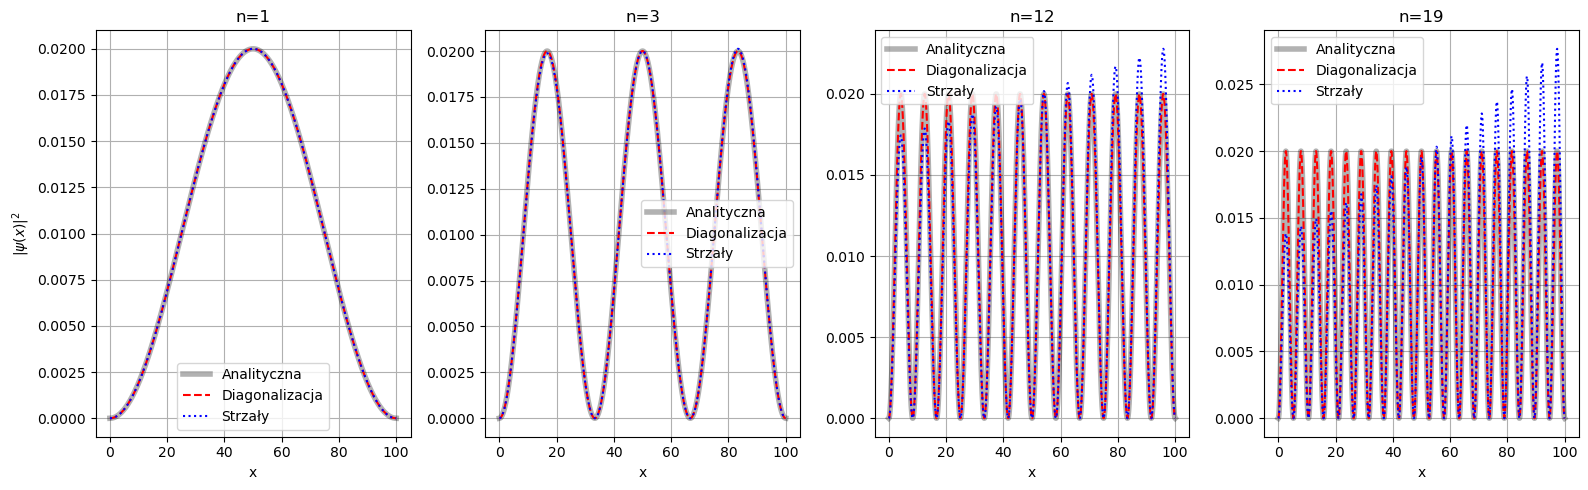

In [20]:
selected(selected_n)

### Analiza wyników

Na podstawie otrzymanych wykresów gęstości prawdopodobieństwa widać, że:

* liczba maksimów rośnie wraz z numerem stanu n
* funkcje falowe są zgodne jakościowo z rozwiązaniem analitycznym dla stanów wzbudzonych 1 i 3
* dla większych n wymagane jest większe N, aby zachować dokładność

Różnice między rozwiązaniem numerycznym a analitycznym maleją wraz ze wzrostem liczby punktów siatki.
### Porównanie metod

Metoda diagonalizacji:

* daje stabilne i dokładne wyniki dla wszystkich stanów
* jest stosunkowo szybka dla umiarkowanych rozmiarów macierzy

Metoda strzałów:

* jest bardziej czuła numerycznie
* trudniejsza w implementacji
* może być mniej stabilna dla wyższych stanów

Czas obliczeń  i dokładność wykresów wskazuje, że metoda diagonalizacji jest bardziej efektywna dla analizowanego problemu.
